## Entrega 2 - Análisis Exploratorio de Datos e Hipótesis sobre F1: Predicción de Posiciones

Antes de formular cualquier hipótesis, es imprescindible fijar los cimientos: definir de manera unívoca
la variable objetivo y comprender por qué los datos ausentes están donde están. En datos reales del
deporte motor no existe el «cero nulos»; lo crucial es discriminar el nulo que representa una falla de
medición del nulo que es consecuencia de la estructura de la competencia.

### Qué cambió desde la Entrega 1

- **Pipeline:** se corrigieron `build_lap_snapshot()` y `build_race_length()` (corte de snapshots sincronizado por el líder y `current_position` según clasificación FIA). **[COMPLETAR con lo que marcó el docente en la Entrega 1 y si quedó resuelto.]**
- **Pregunta del proyecto:** la variable objetivo pasa a ser `finish_position`. Durante este EDA medimos que `total_race_time_s` no reproduce el orden oficial de llegada (coincidencia del 16,1 % ordenando sólo por tiempo) porque saltea las vueltas sin tiempo registrado. La evidencia está en la Sección 1.2.

## Sección 1: El perfil del Dataset

In [ ]:
import os

# --- Archivos de datos y sus IDs de Google Drive ---

# Para 'driver_race_snapshots_2026-09-22.csv'
SNAPSHOTS_PATH = 'driver_race_snapshots_2026-09-22.csv'
ID_DRIVE_SNAPSHOTS = '1DHxV2vLeQHcPOTs-BNT_1Rj0Au-_PJqD'

# Para 'driver_race_features_2026-09-22.csv'
RACE_FEATURES_PATH = 'driver_race_features_2026-09-22.csv'
ID_DRIVE_RACES = '1u_KaAEuml7rchCM8xFRKBoppJCyjiH4j'


# --- Descarga los archivos si no existen localmente ---

if not os.path.exists(SNAPSHOTS_PATH):
    print(f"Descargando {SNAPSHOTS_PATH}...")
    !gdown "$ID_DRIVE_SNAPSHOTS" -O "$SNAPSHOTS_PATH"
else:
    print(f"{SNAPSHOTS_PATH} ya existe localmente.")

if not os.path.exists(RACE_FEATURES_PATH):
    print(f"Descargando {RACE_FEATURES_PATH}...")
    !gdown "$ID_DRIVE_RACES" -O "$RACE_FEATURES_PATH"
else:
    print(f"{RACE_FEATURES_PATH} ya existe localmente.")

print("Descarga de archivos completada.")

Descargando driver_race_snapshots_2026-09-22.csv...
Downloading...
From: https://drive.google.com/uc?id=1DHxV2vLeQHcPOTs-BNT_1Rj0Au-_PJqD
To: /content/driver_race_snapshots_2026-09-22.csv
100% 4.60M/4.60M [00:00<00:00, 28.7MB/s]
Descargando driver_race_features_2026-09-22.csv...
Downloading...
From: https://drive.google.com/uc?id=1u_KaAEuml7rchCM8xFRKBoppJCyjiH4j
To: /content/driver_race_features_2026-09-22.csv
100% 784k/784k [00:00<00:00, 23.4MB/s]
Descarga de archivos completada.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo visual sobrio alineado a la guía metodológica
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Rutas a los datasets consolidados en la capa Silver (post-fix de snapshots)
SNAPSHOTS_PATH = 'driver_race_snapshots_2026-09-22.csv'
RACE_FEATURES_PATH = 'driver_race_features_2026-09-22.csv'

df_snapshots = pd.read_csv(SNAPSHOTS_PATH)
df_races = pd.read_csv(RACE_FEATURES_PATH)

print(f"Snapshots cargados: {df_snapshots.shape[0]:,} filas x {df_snapshots.shape[1]} columnas")
print(f"Driver Race Features: {df_races.shape[0]:,} filas x {df_races.shape[1]} columnas")

Snapshots cargados: 10,635 filas x 59 columnas
Driver Race Features: 2,146 filas x 46 columnas


# Verificación estructural del dataset de snapshots

In [ ]:
KEY = ["season", "round", "driver_code", "lap_cutoff"]
TARGET = "finish_position"

# 1. Tamaño
print("=" * 60)
print("1. TAMAÑO")
print("=" * 60)
print(f"Shape completo:          {df_snapshots.shape}")
print(f"Shape snapshot 100%:     {df_snapshots[df_snapshots['pct_race_complete'] == 1.0].shape}")
print(f"Cortes por piloto-carrera: {sorted(df_snapshots['pct_race_complete'].unique().tolist())}")
print("Una fila = un piloto en una carrera en un punto de corte")
print("         (season × round × driver_code × lap_cutoff)")

# 2. Tipos
print("\n" + "=" * 60)
print("2. TIPOS DE DATOS")
print("=" * 60)
print(df_snapshots.dtypes.value_counts())
obj_cols = df_snapshots.select_dtypes("object").columns.tolist()
print("\nColumnas object (texto):", obj_cols)
print("→ Todas son texto legítimo (nombres, IDs, fecha, compound, status).")
print("  Ninguna numérica quedó codificada como texto.")

# 3. Nulos por columna
print("\n" + "=" * 60)
print("3. NULOS POR COLUMNA (top 10 peores, en %)")
print("=" * 60)
nulos_pct = (df_snapshots.isna().mean() * 100).sort_values(ascending=False)
print(nulos_pct.head(10).round(1).to_string())
print("\nOrigen de los 3 peores:")
print("  q3_s          → solo los 10 más rápidos de Q2 corren Q3 (nulo estructural)")
print("  pit_count/dur → OpenF1 no cubre 2022 y parte de 2023 (faltante real, ver pit_time_available)")
print("  q2_s          → solo los 15 más rápidos de Q1 corren Q2 (nulo estructural)")
print("  avg_lap_time_s_so_far (21,5%) → 20 pts son el corte 0% (estructural: no hay vueltas aún)")

# 3b. Nulos disfrazados de cero
print("\n" + "-" * 60)
print("3b. NULOS DISFRAZADOS DE CERO (pit_time_available == 0)")
print("-" * 60)
sin_pits = df_snapshots[df_snapshots["pit_time_available"] == 0]
print(f"Filas sin datos de boxes: {len(sin_pits)} ({len(sin_pits)/len(df_snapshots)*100:.1f}%)")
print(f"pits_done_so_far en esas filas: valores únicos = {sorted(sin_pits['pits_done_so_far'].dropna().unique())}")
print("→ No es que no pararon: no hay dato. Se filtran con pit_time_available == 1 (ver H4).")

# 4. Columnas sin información
print("\n" + "=" * 60)
print("4. COLUMNAS SIN INFORMACIÓN (nunique <= 1)")
print("=" * 60)
constantes = df_snapshots.columns[df_snapshots.nunique() <= 1].tolist()
print("⚠️  Columnas constantes:" if constantes else "✅ Ninguna columna constante.", constantes if constantes else "")

# 5. Duplicados de clave
print("\n" + "=" * 60)
print("5. DUPLICADOS DE CLAVE PRIMARIA")
print("=" * 60)
dups = df_snapshots[KEY].duplicated().sum()
print(f"Clave: {KEY}  →  Duplicados: {dups}")

# 6. Distribución del objetivo
print("\n" + "=" * 60)
print(f"6. DISTRIBUCIÓN DEL OBJETIVO: {TARGET} (snapshot al 100%)")
print("=" * 60)
snap100 = df_snapshots[df_snapshots["pct_race_complete"] == 1.0]
print(f"Filas: {len(snap100)} · nulos en {TARGET}: {snap100[TARGET].isna().sum()}")
print(f"Pilotos no clasificados (classified=False) que igual tienen posición: {(~snap100['classified']).sum()} "
      f"({(~snap100['classified']).mean()*100:.1f}%)")
dist_obj = snap100[TARGET].value_counts(normalize=True).sort_index()
print((dist_obj * 100).round(1).to_string())
print(f"\n→ Clase más frecuente: {dist_obj.max()*100:.1f}%. Ninguna posición se come el dataset:")
print("  cada carrera reparte exactamente un P1, un P2, etc. P21-P22 existen sólo en 2026 (grilla de 22 autos).")

# 7. Asimetría de numéricas
print("\n" + "=" * 60)
print("7. ASIMETRÍA DE NUMÉRICAS (candidatas a transformar)")
print("=" * 60)
skew = df_snapshots.select_dtypes("number").skew().sort_values(key=abs, ascending=False)
print(skew.head(10).round(3).to_string())
candidatas_skew = skew[abs(skew) > 1].index.tolist()
print(f"\nCriterio: |skew| > 1 → considerar log1p(). Columnas: {len(candidatas_skew)}")
print("→ Sólo importa en las que van al modelo: driver_points_before (skew 2,02) entra en log1p;")
print("  el resto son de fuga o salen (ver Sección 4).")


1. TAMAÑO
Shape completo:          (10635, 59)
Shape snapshot 100%:     (2127, 59)
Cortes por piloto-carrera: [0.0, 0.25, 0.5, 0.75, 1.0]
Una fila = un piloto en una carrera en un punto de corte
         (season × round × driver_code × lap_cutoff)

2. TIPOS DE DATOS
float64    38
object     12
int64       6
bool        3
Name: count, dtype: int64

Columnas object (texto): ['race_date', 'race_name', 'circuit_id', 'circuit_name', 'driver_id', 'driver_code', 'driver_name', 'constructor_id', 'constructor_name', 'team_name', 'compound_at_cutoff', 'status']
→ Todas son texto legítimo (nombres, IDs, fecha, compound, status).
  Ninguna numérica quedó codificada como texto.

3. NULOS POR COLUMNA (top 10 peores, en %)
q3_s                     52.2
pit_count                29.6
pit_duration_min         29.6
pit_duration_mean        29.6
q2_s                     26.8
avg_lap_time_s_so_far    21.5
wind_speed               20.6
humidity                 20.6
pressure                 20.6
track_temp  

# Variable objetivo en versión binaria (si en la Unidad 3 se plantea como clasificación)

In [ ]:
# ============================================================
# La variable objetivo es finish_position (Sección 1.1).
# Si en la Unidad 3 el problema se plantea como clasificación, la versión
# binaria es "¿terminó en el Top 10?". Es la MISMA columna con un corte,
# no un segundo objetivo. Verificamos su balance antes de llegar a modelar.
# ============================================================
snap100 = df_snapshots[df_snapshots["pct_race_complete"] == 1.0].copy()
snap100["top_10"] = (snap100["finish_position"] <= 10).astype(int)

print("=" * 55)
print("DISTRIBUCIÓN DE LA VERSIÓN BINARIA: top_10 = finish_position <= 10")
print("=" * 55)
dist = snap100["top_10"].value_counts(normalize=True).sort_index()
conteo = snap100["top_10"].value_counts().sort_index()
for clase, prop in dist.items():
    label = "Top 10 (clase 1)" if clase == 1 else "Fuera Top 10 (clase 0)"
    print(f"  {label}: {conteo[clase]:>4} filas  ({prop*100:.1f}%)  {'█' * int(prop * 40)}")

ratio = dist.max() / dist.min()
print(f"\nRatio mayoritaria / minoritaria: {ratio:.2f}:1")
print("✅ Balanceado: no hace falta resampling." if ratio < 1.5 else "⚠️ Revisar balance.")
print(f"\nPromedio de Top 10 por carrera:  {snap100.groupby(['season','round'])['top_10'].sum().mean():.1f}")
print(f"Promedio de pilotos por carrera: {snap100.groupby(['season','round']).size().mean():.1f}")


DISTRIBUCIÓN DE LA VERSIÓN BINARIA: top_10 = finish_position <= 10
  Fuera Top 10 (clase 0): 1067 filas  (50.2%)  ████████████████████
  Top 10 (clase 1): 1060 filas  (49.8%)  ███████████████████

Ratio mayoritaria / minoritaria: 1.01:1
✅ Balanceado: no hace falta resampling.

Promedio de Top 10 por carrera:  10.0
Promedio de pilotos por carrera: 20.1


### 1.1. Definición y Distribución de la Variable Objetivo

Nuestra variable objetivo es una columna concreta y medible: **`finish_position`**, la posición oficial
de llegada del piloto en la carrera según la clasificación de la FIA (fuente: Jolpica). Es un entero
entre 1 y 22 y no tiene nulos: la FIA le asigna posición también a los pilotos que abandonan (12,1 % de
las filas al 100 % tienen `classified = False` y aun así tienen posición).

La predicción se hace **al 75 % de la carrera**, con la información disponible en ese corte
(`pct_race_complete == 0.75`). `finish_position` es la respuesta que queremos anticipar; por eso figura
como `LEAKY_COL` en el schema: nunca puede ser una feature.

En la Entrega 1 el objetivo era `total_race_time_s`. Lo abandonamos por un motivo medido, no de
preferencia: ese tiempo no reproduce el orden oficial de llegada (Sección 1.2).

Filas: 2127 · nulos: 0
Posición más frecuente: 106 filas (5.0%) · menos frecuente: P22 con 11 filas


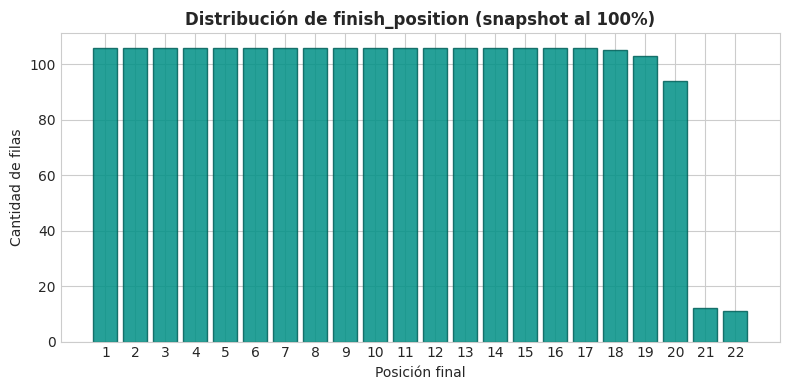

In [ ]:
# Distribución de la variable objetivo: finish_position (snapshot al 100%)
target_data = df_snapshots.loc[df_snapshots['pct_race_complete'] == 1.0, 'finish_position']
frec = target_data.value_counts().sort_index()

print(f"Filas: {len(target_data)} · nulos: {target_data.isna().sum()}")
print(f"Posición más frecuente: {frec.max()} filas ({frec.max()/len(target_data)*100:.1f}%) · "
      f"menos frecuente: P{frec.idxmin()} con {frec.min()} filas")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(frec.index, frec.values, color='#009086', alpha=0.85, edgecolor='#006059')
ax.set_title("Distribución de finish_position (snapshot al 100%)", fontsize=12, fontweight='bold')
ax.set_xlabel("Posición final")
ax.set_ylabel("Cantidad de filas")
ax.set_xticks(frec.index)
plt.tight_layout()
plt.show()


### 1.2. ¿Por qué no `total_race_time_s`?

Si el tiempo total sirviera como objetivo, ordenarlo dentro de cada carrera debería devolver
`finish_position`. Lo probamos con tres ordenamientos sobre los pilotos clasificados:

- **A · sólo tiempo:** menor `total_race_time_s` = mejor posición.
- **B · criterio FIA:** primero más vueltas completadas, y el tiempo como desempate.
- **C · como B, pero restando el tiempo en boxes:** para descartar que el tiempo cuente dos veces el pit lane.

In [ ]:
from scipy.stats import spearmanr

CARRERA = ['season', 'round']
VUELTAS = 'laps_completed_jolpica'   # se usa sólo para este test, nunca como feature

s100 = df_snapshots[df_snapshots['pct_race_complete'] == 1.0].copy()
clas = s100[s100['classified'] & s100['total_race_time_s'].notna()].copy()

clas['r_oficial'] = clas.groupby(CARRERA)['finish_position'].rank(method='first')
clas['t_sin_pits'] = clas['total_race_time_s'] - clas['pit_time_so_far_s'].fillna(0)

def rank_por(df, cols, asc):
    orden = df.sort_values(CARRERA + cols, ascending=[True, True] + asc)
    return orden.groupby(CARRERA).cumcount().add(1).reindex(df.index)

clas['r_A'] = clas.groupby(CARRERA)['total_race_time_s'].rank(method='first')
clas['r_B'] = rank_por(clas, [VUELTAS, 'total_race_time_s'], [False, True])
clas['r_C'] = rank_por(clas, [VUELTAS, 't_sin_pits'],        [False, True])

def medir(df, col):
    por_carrera = df.groupby(CARRERA).apply(
        lambda g: pd.Series({'coinc': (g[col] == g['r_oficial']).mean(),
                             'rho': spearmanr(g[col], g['r_oficial']).statistic,
                             'perfecta': (g[col] == g['r_oficial']).all()}),
        include_groups=False)
    return por_carrera.mean()

resumen_ranking = pd.DataFrame({n: medir(clas, c) for n, c in
                                [('A · solo tiempo', 'r_A'),
                                 ('B · vueltas + tiempo (FIA)', 'r_B'),
                                 ('C · vueltas + tiempo sin boxes', 'r_C')]}).T
print(f"Carreras: {clas.groupby(CARRERA).ngroups} · pilotos clasificados: {len(clas)}\n")
print(resumen_ranking.rename(columns={'coinc': 'coincidencia exacta', 'rho': 'Spearman medio',
                                      'perfecta': 'carreras con orden perfecto'}).round(3).to_string())

coinc_A = round(resumen_ranking.loc['A · solo tiempo', 'coinc'], 3)
coinc_B = round(resumen_ranking.loc['B · vueltas + tiempo (FIA)', 'coinc'], 3)
coinc_C = round(resumen_ranking.loc['C · vueltas + tiempo sin boxes', 'coinc'], 3)


Carreras: 106 · pilotos clasificados: 1870

                                coincidencia exacta  Spearman medio  carreras con orden perfecto
A · solo tiempo                               0.161           0.413                        0.038
B · vueltas + tiempo (FIA)                    0.653           0.915                        0.274
C · vueltas + tiempo sin boxes                0.458           0.860                        0.057


In [ ]:
# ¿Por qué B no llega al 100%? Hipótesis: total_race_time_s saltea las vueltas sin tiempo.
# avg_lap_time_s es el promedio de las vueltas CON tiempo; si el total es la suma de esas mismas
# vueltas, total / promedio da un número entero de vueltas, que puede ser menor que laps_completed.
clas['vueltas_con_tiempo'] = clas['total_race_time_s'] / clas['avg_lap_time_s']
desvio_entero = (clas['vueltas_con_tiempo'] - clas['vueltas_con_tiempo'].round()).abs().max()
clas['vueltas_sin_tiempo'] = clas['laps_completed'] - clas['vueltas_con_tiempo'].round()

print(f"1) total_race_time_s / avg_lap_time_s es entero en todas las filas (desvío máx. {desvio_entero:.1e})")
print("   → el total es la suma de las vueltas con tiempo registrado; no se le suma el tiempo en boxes")
print("     (que ya está dentro de las vueltas de entrada y salida).")

pct_con_huecos = round((clas['vueltas_sin_tiempo'] > 0).mean(), 3)
print(f"\n2) Pilotos clasificados con al menos una vuelta sin tiempo: {pct_con_huecos:.1%}")
print(clas['vueltas_sin_tiempo'].astype(int).value_counts().sort_index().head(6)
      .rename_axis('vueltas sin tiempo').rename('pilotos').to_string())

sin_huecos = clas.groupby(CARRERA)['vueltas_sin_tiempo'].transform('max') == 0
coinc_B_limpias = round(medir(clas[sin_huecos], 'r_B')['coinc'], 3)
print(f"\n3) Criterio B sólo en carreras sin huecos ({clas[sin_huecos].groupby(CARRERA).ngroups} carreras): "
      f"coincidencia = {coinc_B_limpias:.1%}")

resto = clas[sin_huecos & (clas['r_B'] != clas['r_oficial'])]
print(f"\n4) Lo que queda mal ordenado en esas carreras ({len(resto)} pilotos). Ejemplo, España 2025:")
print(clas[clas['season'].eq(2025) & clas['round'].eq(9) & clas['driver_code'].isin(['VER', 'HUL', 'HAM'])]
      .sort_values('total_race_time_s')[['driver_code', 'total_race_time_s', 'finish_position', 'r_B']].to_string(index=False))
print("   VER tiene el menor tiempo del grupo pero terminó 10°: recibió 10 s de sanción.")
print("   Las sanciones de tiempo y las descalificaciones las aplica la FIA; total_race_time_s no.")

ej = clas[(clas['season'] == 2022) & (clas['round'] == 1) & clas['driver_code'].isin(['SAI', 'RUS'])]
print("\nEjemplo del sesgo por huecos (Bahréin 2022): RUS terminó detrás de SAI pero 'tardó' 145 s menos")
print(ej[['driver_code', 'finish_position', 'vueltas_sin_tiempo', 'total_race_time_s']].to_string(index=False))


1) total_race_time_s / avg_lap_time_s es entero en todas las filas (desvío máx. 2.1e-14)
   → el total es la suma de las vueltas con tiempo registrado; no se le suma el tiempo en boxes
     (que ya está dentro de las vueltas de entrada y salida).

2) Pilotos clasificados con al menos una vuelta sin tiempo: 36.5%
vueltas sin tiempo
0    1187
1     259
2     189
3     132
4      37
5      31

3) Criterio B sólo en carreras sin huecos (43 carreras): coincidencia = 87.8%

4) Lo que queda mal ordenado en esas carreras (95 pilotos). Ejemplo, España 2025:
driver_code  total_race_time_s  finish_position  r_B
        VER           5589.201               10    5
        HUL           5591.023                5    6
        HAM           5592.883                6    7
   VER tiene el menor tiempo del grupo pero terminó 10°: recibió 10 s de sanción.
   Las sanciones de tiempo y las descalificaciones las aplica la FIA; total_race_time_s no.

Ejemplo del sesgo por huecos (Bahréin 2022): RUS terminó d

In [ ]:
# Casos atípicos de total_race_time_s: muestran por qué no sirve como objetivo

snap100 = df_snapshots[df_snapshots['pct_race_complete'] == 1.0].copy()
snap100['total_race_time_min'] = snap100['total_race_time_s'] / 60

cols = [
    'season',
    'round',
    'driver_id',
    'total_race_time_min',
    'laps_completed_jolpica',
    'finish_position'
]

raros = snap100[
    (snap100['total_race_time_min'] < 70) &
    (snap100['classified'])
].sort_values('total_race_time_min')

print(
    f"Clasificados con tiempo < 70 min: {len(raros)}  "
    "(Japón 2022: suspensión por lluvia EXCLUIDA del tiempo)"
)
print(raros[cols].head(6).to_string(index=False))

bloque_140 = snap100[
    snap100['total_race_time_min'].between(130, 150)
].sort_values('finish_position')

print(
    f"\nFilas cerca de 140 min: {len(bloque_140)}  "
    "(Mónaco 2024: bandera roja en la vuelta 1 INCLUIDA)"
)
print(bloque_140[cols].to_string(index=False))

mon25 = df_snapshots[
    (df_snapshots['season'] == 2024) &
    (df_snapshots['round'] == 8) &
    (df_snapshots['driver_code'] == 'LEC') &
    (df_snapshots['pct_race_complete'] == 0.25)
]

print(
    f"\nMónaco 2024, LEC al 25%: promedio de vuelta hasta el corte = "
    f"{mon25['avg_lap_time_s_so_far'].iloc[0]:.0f} s "
    "(una vuelta normal en Mónaco ronda los 75 s: la suspensión está adentro)"
)


Clasificados con tiempo < 70 min: 18  (Japón 2022: suspensión por lluvia EXCLUIDA del tiempo)
 season  round      driver_id  total_race_time_min  laps_completed_jolpica  finish_position
   2022     18 max_verstappen            43.629717                      28                1
   2022     18        leclerc            44.107233                      28                3
   2022     18          perez            44.135283                      28                2
   2022     18           ocon            44.423600                      28                4
   2022     18       hamilton            44.490683                      28                5
   2022     18         alonso            44.628700                      28                7

Filas cerca de 140 min: 16  (Mónaco 2024: bandera roja en la vuelta 1 INCLUIDA)
 season  round      driver_id  total_race_time_min  laps_completed_jolpica  finish_position
   2024      8        leclerc           140.294950                      78               

**Qué nos dicen los números de la Sección 1.2:**

- Ordenar sólo por tiempo coincide con el orden oficial en el **16,1 %** de los casos. Ordenar como la
  FIA (vueltas primero, tiempo como desempate) sube a **65,3 %**. Sacar el tiempo en boxes empeora
  (**45,8 %**): el tiempo no cuenta dos veces el pit lane.
- La causa principal es de construcción: `total_race_time_s` es la suma de las `lap_time_s` **no nulas**.
  El **36,5 %** de los pilotos clasificados tiene al menos una vuelta sin tiempo (típicamente bajo safety
  car o bandera roja), y esas vueltas simplemente no se suman: el piloto parece más rápido de lo que fue.
- En las 43 carreras sin vueltas faltantes, el criterio FIA coincide en el **87,8 %**; lo que queda son
  sanciones de 5/10 s y descalificaciones, que la FIA aplica y el tiempo no.
- Las banderas rojas se tratan distinto según la carrera: en Japón 2022 la suspensión quedó fuera
  (≈44 min), en Mónaco 2024 quedó dentro de la vuelta 1 (≈140 min). La cola derecha del tiempo no es
  "un circuito lento": es una suspensión de 41 minutos.

**Decisión:** el objetivo es `finish_position`. Arreglar `total_race_time_s` exige reconstruir las
vueltas faltantes y aplicar sanciones en el pipeline; queda anotado como pendiente, no como objetivo.

### 1.3. Auditoría de Nulos: Faltantes Reales vs. Nulos Estructurales

En este dataset coexisten dos naturalezas de nulos completamente distintas:

1. **Nulos estructurales** (deben estar vacíos por diseño):
   - `q3_s` (52,2 %): sólo los 10 más rápidos de Q2 disputan la Q3.
   - `q2_s` (26,8 %): los eliminados en Q1 no corren Q2.
   - `avg_lap_time_s_so_far`, `pits_done_so_far`, `current_position` en `pct_race_complete = 0.0`:
     antes de largar no hay vueltas ni paradas. Explica 20 de los 21,5 puntos de nulos de
     `avg_lap_time_s_so_far`.
2. **Faltantes reales** (el dato existió pero no lo tenemos):
   - Meteorológicas (`air_temp`, `track_temp`, `humidity`, `wind_speed`, `rainfall_max`, 20,5 %):
     falta **toda la temporada 2022** (100 % nulo en 2022, 0 % en el resto), porque la API de OpenF1
     empieza a cubrir en 2023.
   - `pit_count`, `pit_duration_*` (29,6 %): mismo origen — toda 2022 y el 31,6 % de 2023.
   - **Nulos disfrazados de cero:** en esas mismas carreras `pits_done_so_far` y `pit_time_so_far_s`
     valen 0 en lugar de NaN. Se identifican con `pit_time_available == 0` y se excluyen de H4.

In [ ]:
# Demostración cuantitativa: nulos de qualy por posición de largada
df_qualy_nulls = df_races[['grid_position', 'q1_s', 'q2_s', 'q3_s']].copy()
df_qualy_nulls['grupo_grilla'] = pd.cut(
    df_qualy_nulls['grid_position'], bins=[0, 10, 15, 25],
    labels=['Top 10 (Q3)', 'Puestos 11-15 (Q2)', 'Puestos 16-22 (Q1)'])
print("Porcentaje de nulos por grupo de largada:")
print((df_qualy_nulls.groupby('grupo_grilla', observed=True)[['q1_s', 'q2_s', 'q3_s']]
       .apply(lambda g: g.isna().mean() * 100)).round(1))
print("(Los ~6-12% fuera de patrón: la grilla difiere de la qualy por sanciones de motor o largada desde boxes.)")

print("\nNulos por temporada (%): clima y boxes")
print((df_races.groupby('season')[['air_temp', 'pit_count']].apply(lambda g: g.isna().mean()) * 100).round(1))

print("\npits_done_so_far al 75% según haya datos de boxes:")
s75 = df_snapshots[df_snapshots['pct_race_complete'] == 0.75]
print(s75.groupby('pit_time_available')['pits_done_so_far'].describe()[['count', 'mean', 'max']])


Porcentaje de nulos por grupo de largada:
                    q1_s  q2_s  q3_s
grupo_grilla                        
Top 10 (Q3)          0.9   1.1   6.0
Puestos 11-15 (Q2)   0.9  12.3  97.2
Puestos 16-22 (Q1)   5.9  90.4  97.8
(Los ~6-12% fuera de patrón: la grilla difiere de la qualy por sanciones de motor o largada desde boxes.)

Nulos por temporada (%): clima y boxes
        air_temp  pit_count
season                     
2022       100.0      100.0
2023         0.0       31.6
2024         0.0        4.6
2025         0.0        4.8
2026         0.0        8.1

pits_done_so_far al 75% según haya datos de boxes:
                     count      mean  max
pit_time_available                       
False                558.0  0.000000  0.0
True                1569.0  1.616316  5.0


## Sección 2: El Marco Metodológico

Adoptamos de forma estricta las tres plantillas formales, las métricas de tamaño de efecto y el sistema
de semáforo con tope de dos movimientos dictado por la cátedra.

In [ ]:
# Umbrales convencionales del semaforo
CORTES = {
    "separacion": (0.2, 0.8),
    "eta2": (0.05, 0.25),
    "correlacion": (0.2, 0.6),
    "brecha": (0.05, 0.15)
}

def semaforo(valor, medida):
    """Devuelve la zona ('rojo', 'amarillo', 'verde') segun el valor absoluto de la medida."""
    bajo, alto = CORTES[medida]
    v = abs(valor)
    return "rojo" if v < bajo else "verde" if v > alto else "amarillo"

def asociacion(x, y):
    """Calcula Pearson, Spearman y la brecha (Spearman - Pearson) entre dos numericas."""
    mask = x.notna() & y.notna()
    x_clean, y_clean = x[mask], y[mask]
    p = x_clean.corr(y_clean)
    s = x_clean.corr(y_clean, method="spearman")
    return pd.Series({"pearson": p, "spearman": s, "brecha": s - p}).round(3)

def eta2(numerica, categoria):
    """Proporcion de varianza explicada (razon de correlacion eta cuadrado)."""
    sub = pd.DataFrame({"num": numerica, "cat": categoria}).dropna()
    mean_total = sub["num"].mean()
    ss_total = ((sub["num"] - mean_total) ** 2).sum()
    group_means = sub.groupby("cat")["num"].mean()
    group_counts = sub.groupby("cat")["num"].count()
    ss_between = (group_counts * (group_means - mean_total) ** 2).sum()
    return round(ss_between / ss_total, 3)

def separacion(x, y):
    """Distancia entre dos grupos normalizada en desviaciones estandar (d de Cohen)."""
    x_clean, y_clean = x.dropna(), y.dropna()
    return round(abs(x_clean.mean() - y_clean.mean()) / np.sqrt((x_clean.std() ** 2 + y_clean.std() ** 2) / 2), 3)

def ficha_resultado(nombre, valor, medida, decimales=3):
    """
    Genera el texto de resultado listo para pegar en la celda Markdown,
    siempre a partir del valor real calculado -- nunca escrito a mano.
    Esto evita que la interpretacion quede desincronizada del codigo
    si el dataset cambia en una proxima corrida.
    """
    zona = semaforo(valor, medida)
    emoji = {"verde": "🟢", "amarillo": "🟡", "rojo": "🔴"}[zona]
    signo = "+" if valor >= 0 else ""
    texto = (f"Resultado: coeficiente = {signo}{valor:.{decimales}f} "
             f"({emoji} {zona.capitalize()})")
    print(f"--- {nombre} ---")
    print(texto)
    return valor, zona

**Reglas de Decisión del Semáforo**

- **Verde:** El efecto es contundente; la hipótesis se confirma. No se realizan más movimientos.
- **Rojo:** El efecto es despreciable; la hipótesis se refuta. Se descarta de inmediato.
- **Amarillo:** Zona de ambigüedad. Habilita a realizar hasta dos movimientos (partir la
  población, controlar una variable confusora o cambiar de escala), siempre guiados por lo que
  se observa en el gráfico.
- Si tras el segundo movimiento el número persiste en amarillo, la hipótesis se declara inconclusa.

## Sección 3: Las Cuatro Hipótesis (Fichas de Decisión)

Las cuatro hipótesis usan como respuesta la variable objetivo, `finish_position`. Las que miran
información "en carrera" (H1, H4) se evalúan en el snapshot del 75 %, que es el momento en que el
modelo va a predecir.

---

### H1 · Ganar posiciones respecto a la largada (75% de carrera) predice mejor posición final

*Pregunta: Predice · Plantilla: Asociación*

1. **Afirmación.** El avance de posiciones que logra un piloto respecto a su grilla de partida
   hasta el 75% de la carrera predice con fuerza que alcanzará una mejor posición de llegada
   (menor `finish_position`).
2. **Qué espero ver.** Una correlación negativa sólida: a mayor cantidad de puestos ganados,
   menor número de posición final. En el scatter plot, una nube descendente compacta.
3. **Medida y gráfico.** Correlación de Pearson y Spearman entre la ganancia neta
   (`grid_position - current_position`, ya disponible en el silver como `position_gain_loss`)
   y `finish_position` en el snapshot de carrera al 75% (`pct_race_complete == 0.75`).

In [ ]:
# Extraccion del snapshot al 75% de carrera
snap75 = df_snapshots[df_snapshots['pct_race_complete'] == 0.75].copy()

# La ganancia de posiciones ya viene calculada en el silver post-fix como position_gain_loss
# (grid_position - current_position; positivo = avanzo hacia la punta). La recalculamos aqui
# solo para dejar explicita la formula.
snap75['posiciones_ganadas'] = snap75['grid_position'] - snap75['current_position']
assert (snap75['posiciones_ganadas'] - snap75['position_gain_loss']).abs().max() < 1e-9, \
    "position_gain_loss del silver no coincide con grid_position - current_position"

h1_pool = asociacion(snap75['posiciones_ganadas'], snap75['finish_position'])
print("H1 - Pool general al 75% de carrera:")
print(h1_pool)
_, zona_h1_pool = ficha_resultado("H1 pool", h1_pool['pearson'], 'correlacion')

H1 - Pool general al 75% de carrera:
pearson    -0.249
spearman   -0.191
brecha      0.057
dtype: float64
--- H1 pool ---
Resultado: coeficiente = -0.249 (🟡 Amarillo)


**Resultado inicial.** El coeficiente de correlación de Pearson global da **-0,249**
(🟡 Amarillo), con Spearman -0,191. La dirección es la esperada (negativa): a mayor ganancia de
posiciones respecto a la grilla, mejor (menor) `finish_position`. La asociación lineal sobre todo
el pelotón es moderada y cae en la franja amarilla. Habilita a explorar un movimiento; miramos el
gráfico para entender por qué la relación global no es más nítida.

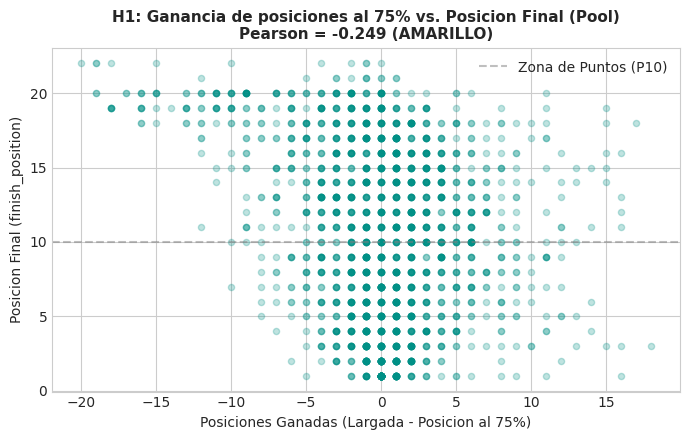

In [ ]:
plt.figure(figsize=(7, 4.5))
plt.scatter(snap75['posiciones_ganadas'], snap75['finish_position'],
            alpha=0.25, color='#009086', s=20)
plt.title(f"H1: Ganancia de posiciones al 75% vs. Posicion Final (Pool)\n"
          f"Pearson = {h1_pool['pearson']} ({semaforo(h1_pool['pearson'], 'correlacion').upper()})",
          fontsize=11, fontweight='bold')
plt.xlabel("Posiciones Ganadas (Largada - Posicion al 75%)")
plt.ylabel("Posicion Final (finish_position)")
plt.axhline(10, color='gray', linestyle='--', alpha=0.5, label='Zona de Puntos (P10)')
plt.legend()
plt.tight_layout()
plt.show()

**Qué se ve en el gráfico:** El gráfico muestra una asimetría estructural:

- Los pilotos que largaron en el **frente de la grilla (Top 10)** tienen un margen de ganancia muy
  acotado hacia adelante (+1 a +3 puestos máximo), pero cuando pierden o mantienen la posición,
  su destino final queda fuertemente determinado.
- Los pilotos que largaron en el **fondo (puestos 11 a 20)** tienen mucha más dispersión: un
  piloto puede haber ganado varios puestos temporalmente por estirar su parada en boxes, pero
  volverá a caer cuando ingrese a pits. Por lo tanto, la dinámica del pelotón de punta difiere de
  la del fondo.

Corresponde realizar el **Movimiento 1: Partir la población por banda de largada**.

Subgrupo Adelante (Grid <= 10): Pearson = -0.646 -> Zona: verde
Subgrupo Atras (Grid > 10):     Pearson = -0.49 -> Zona: amarillo


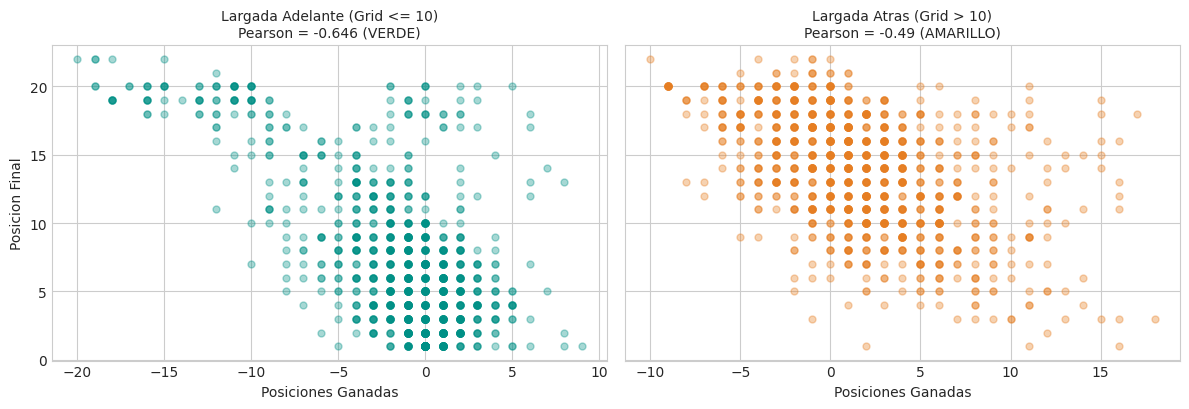

In [ ]:
adelante = snap75[snap75['grid_position'] <= 10]
atras = snap75[snap75['grid_position'] > 10]

h1_adelante = asociacion(adelante['posiciones_ganadas'], adelante['finish_position'])
h1_atras = asociacion(atras['posiciones_ganadas'], atras['finish_position'])

print(f"Subgrupo Adelante (Grid <= 10): Pearson = {h1_adelante['pearson']} -> Zona: {semaforo(h1_adelante['pearson'], 'correlacion')}")
print(f"Subgrupo Atras (Grid > 10):     Pearson = {h1_atras['pearson']} -> Zona: {semaforo(h1_atras['pearson'], 'correlacion')}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)

axes[0].scatter(adelante['posiciones_ganadas'], adelante['finish_position'],
                 alpha=0.35, color='#009086', s=25)
axes[0].set_title(f"Largada Adelante (Grid <= 10)\nPearson = {h1_adelante['pearson']} "
                   f"({semaforo(h1_adelante['pearson'], 'correlacion').upper()})", fontsize=10)
axes[0].set_xlabel("Posiciones Ganadas")
axes[0].set_ylabel("Posicion Final")

axes[1].scatter(atras['posiciones_ganadas'], atras['finish_position'],
                 alpha=0.35, color='#e67e22', s=25)
axes[1].set_title(f"Largada Atras (Grid > 10)\nPearson = {h1_atras['pearson']} "
                   f"({semaforo(h1_atras['pearson'], 'correlacion').upper()})", fontsize=10)
axes[1].set_xlabel("Posiciones Ganadas")

plt.tight_layout()
plt.show()

**Resultado tras el movimiento:**

- En el pelotón de punta (`grid <= 10`), la correlación se intensifica a **-0,646** (🟢 Verde).
- En el pelotón de atrás (`grid > 10`), la correlación es **-0,490** (🟡 Amarillo): las
  estrategias alternativas de neumáticos y paradas tardías introducen mayor variabilidad.

**Qué hago con eso. Decisión:** Conclusión **mixta por subgrupo**: el efecto de la ganancia depende de
desde dónde se largó. Como `position_gain_loss = grid_position - current_position` es una combinación
lineal exacta de dos columnas que ya entran, no se agrega aparte. Lo que H1 aporta al modelo es la
**interacción** `grid_position × current_position` (o un modelo de árboles que la capture solo).

---

### H2 · El standing en el campeonato antes de la carrera se asocia con dónde termina

*Pregunta: Responde · Plantilla: Asociación*

1. **Afirmación.** El standing acumulado en el campeonato con el que un piloto llega al fin de
   semana (`driver_standing_before`) se asocia directamente con la posición en la que termina la
   carrera (`finish_position`).
2. **Qué espero ver.** Los pilotos mejor rankeados en el torneo (1°, 2°, 3°) deberían terminar
   consistentemente en los primeros puestos; los de peor ranking, en el fondo. Nube ascendente con
   correlación positiva fuerte.
3. **Medida y gráfico.** Correlación de Pearson entre `driver_standing_before` y `finish_position`,
   con scatter coloreado por escalón de equipo.

In [ ]:
df_h2 = df_races[['driver_standing_before', 'finish_position', 'constructor_name', 'grid_position']].dropna(
    subset=['driver_standing_before', 'finish_position']
)

h2_res = asociacion(df_h2['driver_standing_before'], df_h2['finish_position'])
print("H2 - Asociacion bruta entre Standing previo y Posicion Final:")
print(h2_res)
ficha_resultado("H2 pool", h2_res['pearson'], 'correlacion')

H2 - Asociacion bruta entre Standing previo y Posicion Final:
pearson     0.596
spearman    0.600
brecha      0.004
dtype: float64
--- H2 pool ---
Resultado: coeficiente = +0.596 (🟡 Amarillo)


(np.float64(0.596), 'amarillo')

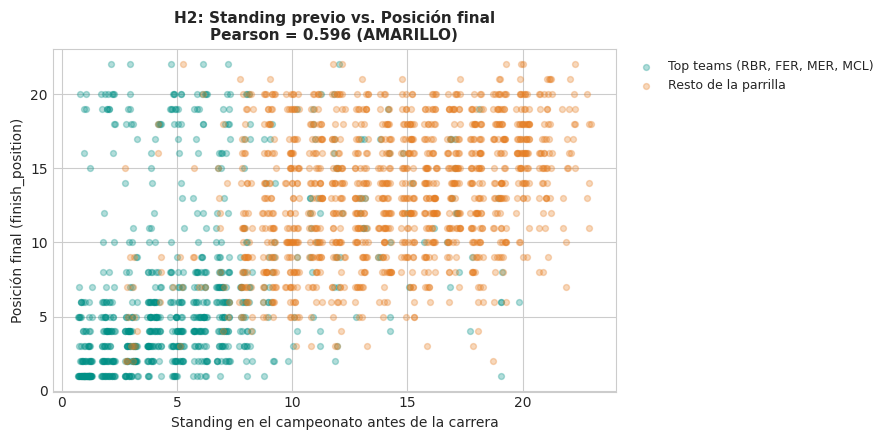

In [ ]:
top_teams = ['Red Bull', 'Ferrari', 'Mercedes', 'McLaren']
es_top = df_h2['constructor_name'].isin(top_teams)
jitter = np.random.default_rng(0).uniform(-0.3, 0.3, len(df_h2))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(df_h2.loc[es_top, 'driver_standing_before'] + jitter[es_top], df_h2.loc[es_top, 'finish_position'],
           alpha=0.3, s=18, color='#009086', label='Top teams (RBR, FER, MER, MCL)')
ax.scatter(df_h2.loc[~es_top, 'driver_standing_before'] + jitter[~es_top], df_h2.loc[~es_top, 'finish_position'],
           alpha=0.3, s=18, color='#e67e22', label='Resto de la parrilla')
ax.set_title(f"H2: Standing previo vs. Posición final\nPearson = {h2_res['pearson']} "
             f"({semaforo(h2_res['pearson'], 'correlacion').upper()})", fontsize=11, fontweight='bold')
ax.set_xlabel("Standing en el campeonato antes de la carrera")
ax.set_ylabel("Posición final (finish_position)")
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9, frameon=False)
plt.tight_layout()
plt.show()


**Resultado inicial.** La correlación de Pearson da **0,596** (🟡 Amarillo, rozando el umbral
verde de 0,60).

**Qué se ve en el gráfico:** la nube no es una sola: son dos bloques casi separados por color. Los
pilotos de los cuatro equipos de punta ocupan la esquina de standing bajo y posición baja; el resto de
la parrilla, la esquina opuesta. Buena parte de la correlación puede venir de la **distancia entre los
dos bloques** (el auto) y no de la pendiente dentro de cada uno (el piloto).

**Movimiento 1: Controlar por escalón de equipo.** Si el standing sólo mide la competitividad del
monoplaza, al separar los dos bloques la correlación debería desplomarse.

In [ ]:
top_teams = ['Red Bull', 'Ferrari', 'Mercedes', 'McLaren']
df_top = df_h2[df_h2['constructor_name'].isin(top_teams)]
df_mid_bottom = df_h2[~df_h2['constructor_name'].isin(top_teams)]

r_top = round(df_top['driver_standing_before'].corr(df_top['finish_position']), 3)
r_mid = round(df_mid_bottom['driver_standing_before'].corr(df_mid_bottom['finish_position']), 3)

print(f"Controlando Equipo - Top Teams:  Pearson = {r_top} -> Zona: {semaforo(r_top, 'correlacion')}")
print(f"Controlando Equipo - Mid/Bottom: Pearson = {r_mid} -> Zona: {semaforo(r_mid, 'correlacion')}")

Controlando Equipo - Top Teams:  Pearson = 0.337 -> Zona: amarillo
Controlando Equipo - Mid/Bottom: Pearson = 0.331 -> Zona: amarillo


Al separar por escalón de equipo, la correlación cae de **0,596** a **0,337** (Top Teams) y **0,331**
(Resto), permaneciendo en 🟡 Amarillo. Buena parte de la asociación inicial era la distancia entre
bloques. Dentro de cada bloque del gráfico todavía queda pendiente: sospechamos que el standing
también refleja desde dónde larga el piloto (quien va adelante en el campeonato suele clasificar
adelante). Sigue en amarillo, así que se habilita el segundo (y último) movimiento.

**Movimiento 2: Controlar por posición de largada (`grid_position`).** ¿Aporta el standing
información fresca una vez que ya sabemos desde qué cajón de la grilla larga el piloto?

In [ ]:
df_grid_top = df_h2[df_h2['grid_position'] <= 10]
df_grid_bot = df_h2[df_h2['grid_position'] > 10]

r_grid_top = round(df_grid_top['driver_standing_before'].corr(df_grid_top['finish_position']), 3)
r_grid_bot = round(df_grid_bot['driver_standing_before'].corr(df_grid_bot['finish_position']), 3)

print(f"Controlando Largada - Grid <= 10: Pearson = {r_grid_top} -> Zona: {semaforo(r_grid_top, 'correlacion')}")
print(f"Controlando Largada - Grid > 10:  Pearson = {r_grid_bot} -> Zona: {semaforo(r_grid_bot, 'correlacion')}")

Controlando Largada - Grid <= 10: Pearson = 0.433 -> Zona: amarillo
Controlando Largada - Grid > 10:  Pearson = 0.399 -> Zona: amarillo


Resultado tras los dos movimientos: controlando la largada, los coeficientes se sitúan en
**0,433** (Grid <= 10) y **0,399** (Grid > 10), permaneciendo firmemente en la zona amarilla.

**Qué hago con eso.** Habiendo alcanzado el tope reglamentario de dos movimientos sin alcanzar el
verde ni caer al rojo, la hipótesis queda formalmente declarada como **INCONCLUSA** (🟡).
**Decisión:** la posición en el torneo previo no puede tomarse como un factor causal aislado.
Contiene una mezcla inseparable entre el rendimiento histórico del coche y la clasificación del
sábado. Para resolverla en el modelo, no se usará como predictor prioritario autónomo, sino que se
dejará que un modelo multivariado con regularización evalúe si aporta señal marginal por encima de
`constructor_name` y `grid_position`.

---

### H3 · El equipo explica buena parte de dónde termina un piloto

*Pregunta: Predice · Plantilla: Comparación (η²)*

1. **Afirmación.** El equipo constructor para el cual corre un piloto explica una porción
   sustancial de la variabilidad de su posición final (`finish_position`), por encima de las
   contingencias individuales de cada carrera.
2. **Qué espero ver.** Un η² elevado (> 0,25), con una separación marcada entre las medias y
   medianas de los equipos dominantes (Red Bull, Ferrari, Mercedes, McLaren) y los equipos de cola
   de tabla (Sauber, Williams, Haas).
3. **Medida y gráfico.** Razón de correlación (η²) de `finish_position` agrupada por
   `constructor_name`, complementada con gráfico de dispersión de promedios e intervalos de
   llegada.

In [ ]:
df_h3 = df_races[['constructor_name', 'finish_position']].dropna()

# Calculo formal de eta cuadrado
h3_eta2 = eta2(df_h3['finish_position'], df_h3['constructor_name'])
print(f"H3 - eta2 de finish_position segun constructor_name: {h3_eta2}")
ficha_resultado("H3 eta2", h3_eta2, 'eta2')

# Resumen de medias de posicion de llegada por constructor
team_summary = df_h3.groupby('constructor_name')['finish_position'].agg(['count', 'mean', 'std']).sort_values('mean')
print("\nPosicion media de llegada por Constructor:")
print(team_summary.round(2))

H3 - eta2 de finish_position segun constructor_name: 0.326
--- H3 eta2 ---
Resultado: coeficiente = +0.326 (🟢 Verde)

Posicion media de llegada por Constructor:
                  count   mean   std
constructor_name                    
Red Bull            212   6.15  5.92
Mercedes            212   6.44  5.08
Ferrari             212   6.73  5.63
McLaren             212   7.25  5.77
Aston Martin        211  12.19  4.93
RB F1 Team          124  12.24  4.22
Alpine F1 Team      212  12.28  4.62
Audi                 28  12.82  4.12
Haas F1 Team        212  13.51  3.89
AlphaTauri           88  13.57  3.64
Alfa Romeo           88  13.60  3.79
Williams            211  14.13  4.17
Sauber               96  14.59  3.87
Cadillac F1 Team     28  17.86  2.62


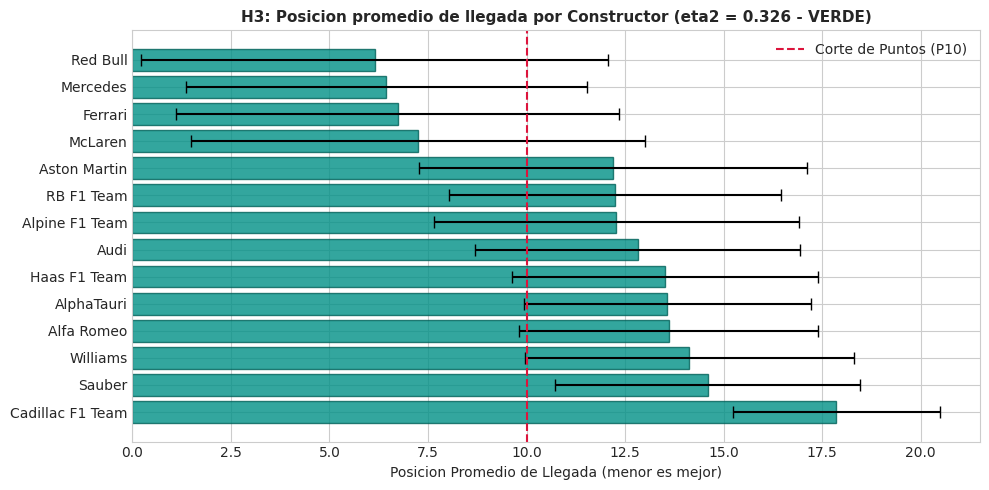

In [ ]:
plt.figure(figsize=(10, 5))
teams_ordered = team_summary.index.tolist()
means = team_summary['mean'].values
stds = team_summary['std'].values

plt.barh(teams_ordered, means, xerr=stds, color='#009086', alpha=0.8, capsize=4, edgecolor='#006059')
plt.axvline(10, color='crimson', linestyle='--', label='Corte de Puntos (P10)')
plt.gca().invert_yaxis()
plt.title(f"H3: Posicion promedio de llegada por Constructor "
          f"(eta2 = {h3_eta2} - {semaforo(h3_eta2, 'eta2').upper()})", fontsize=11, fontweight='bold')
plt.xlabel("Posicion Promedio de Llegada (menor es mejor)")
plt.legend()
plt.tight_layout()
plt.show()

**Resultado.** η² = **0,326** (🟢 Verde). Casi un tercio (32,6 %) de la varianza de la posición final
se explica sólo por qué auto maneja el piloto. Las escuderías líderes (Red Bull, Mercedes, Ferrari,
McLaren) promedian conjuntamente un ~6,6° puesto, mientras que las del fondo (Williams, Sauber,
Cadillac) promedian entre el 14° y el 18° puesto.

**Movimiento.** Ninguno. El resultado cae directamente en zona verde, lo que termina la hipótesis
de inmediato.

**Qué hago con eso. Decisión:** Hipótesis **CONFIRMADA**. El equipo entra al modelo como feature de
primer orden. Un cuidado para la Entrega 3: `constructor_name` parte un mismo equipo en varias
categorías según el nombre comercial de cada año (AlphaTauri → RB; Alfa Romeo → Sauber → Audi), lo que
deja categorías con 28 filas. Para el encoding conviene agrupar por linaje de equipo.

In [ ]:
# Sólo filas con datos reales de boxes: en 2022 y parte de 2023 pits_done_so_far vale 0 por falta de dato
df_h4 = snap75.loc[snap75['pit_time_available'] == 1, ['pits_done_so_far', 'finish_position']].dropna()
print(f"Filas al 75% con datos de boxes: {len(df_h4)} de {len(snap75)} "
      f"(se excluyen {len(snap75) - len(df_h4)} ceros que en realidad son faltantes)")

h4_res = asociacion(df_h4['pits_done_so_far'], df_h4['finish_position'])
print("H4 - Asociacion entre Paradas al 75% y Posicion Final:")
print(h4_res)
ficha_resultado("H4 pool", h4_res['pearson'], 'correlacion')


Filas al 75% con datos de boxes: 1569 de 2127 (se excluyen 558 ceros que en realidad son faltantes)
H4 - Asociacion entre Paradas al 75% y Posicion Final:
pearson    -0.079
spearman   -0.070
brecha      0.009
dtype: float64
--- H4 pool ---
Resultado: coeficiente = -0.079 (🔴 Rojo)


(np.float64(-0.079), 'rojo')

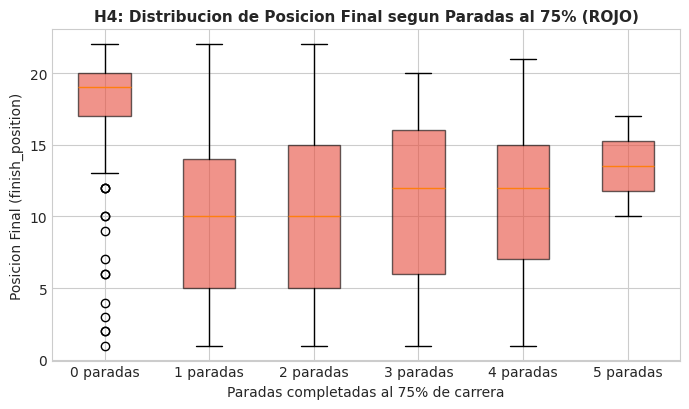

In [ ]:
plt.figure(figsize=(7, 4.2))
paradas_ordenadas = sorted(df_h4['pits_done_so_far'].unique())
box_data = [df_h4.loc[df_h4['pits_done_so_far'] == p, 'finish_position'].values for p in paradas_ordenadas]

plt.boxplot(box_data, tick_labels=[f"{int(p)} paradas" for p in paradas_ordenadas],
            patch_artist=True, boxprops=dict(facecolor='#e74c3c', alpha=0.6))
plt.title(f"H4: Distribucion de Posicion Final segun Paradas al 75% "
          f"({semaforo(h4_res['pearson'], 'correlacion').upper()})", fontsize=11, fontweight='bold')
plt.xlabel("Paradas completadas al 75% de carrera")
plt.ylabel("Posicion Final (finish_position)")
plt.tight_layout()
plt.show()

**Resultado.** Sobre las 1 569 filas con datos reales de boxes, el coeficiente de Pearson es
**-0,079** (🔴 Rojo). La asociación lineal es prácticamente cero. (Con los ceros falsos de 2022 incluidos
daba -0,043: el resultado no cambia de zona, pero el número correcto es el filtrado.)

**Movimiento.** Ninguno. La regla del semáforo es taxativa: el color rojo termina la hipótesis sin
habilitar movimientos adicionales.

**Qué hago con eso. Decisión:** Hipótesis **REFUTADA**. Por qué ocurre esto en el dominio: la
estrategia es relativa. Un piloto con 2 paradas puede estar 1° porque ya completó su plan de carrera,
mientras otro con 1 parada está transitoriamente 2° pero adeuda su ingreso a boxes. **Impacto en el
modelo:** `pits_done_so_far` sale. Tampoco lo reemplazamos por `pit_time_so_far_s`: da -0,034 (🔴) y
además absorbe suspensiones por bandera roja como si fueran tiempo en boxes (máximo: 2 590 s).

## Sección 4: Tabla de Columnas Candidatas (Entregable Entrega 3)

Antes de suministrar cualquier columna a los modelos predictivos, se realiza el **chequeo de fuga
(data leakage)**:

> «¿Existiría esta columna en el momento exacto en que se realiza la predicción?»

Si una variable recopila datos que suceden al concluir la carrera o incluye la respuesta codificada
bajo otro nombre, no es una feature legítima: es fuga.

La zona de cada columna sale de un número: las de las hipótesis toman su resultado; el resto se mide
abajo contra `finish_position` en el snapshot del **75 %**, que es el momento de predicción.

In [ ]:
# Zonas medidas (snapshot al 75%) para las columnas que no pasaron por una hipótesis
def zona_de(col, df=snap75):
    r = asociacion(df[col], df['finish_position'])['pearson']
    return r, semaforo(r, 'correlacion')

medidas = {c: zona_de(c) for c in ['current_position', 'grid_position', 'driver_points_before',
                                    'air_temp', 'track_temp']}
medidas['pit_time_so_far_s'] = zona_de('pit_time_so_far_s', snap75[snap75['pit_time_available'] == 1])
for c, (r, z) in medidas.items():
    print(f"{c:<22} Pearson = {r:+.3f} -> {z}")
skew_pts = snap75['driver_points_before'].skew()
skew_pts_log = np.log1p(snap75['driver_points_before']).skew()
print(f"\ndriver_points_before: skew {skew_pts:.2f} -> con log1p {skew_pts_log:.2f}")

def z(r, zona):
    return f"{zona} ({r:+.3f})"

candidatas_data = [
    # Columna, Qué mide, Zona (número), Decisión, ¿Existiría al predecir?
    ("current_position", "Posición en pista al 75% de las vueltas (clasificación FIA, corte por el líder)",
     z(*medidas['current_position']), "Entra", "Sí - conocida en la vuelta de corte"),
    ("grid_position", "Posición de largada",
     z(*medidas['grid_position']), "Entra", "Sí - definida antes de largar"),
    ("grid_position × current_position", "Interacción: el efecto de ganar puestos depende de la largada",
     f"H1: verde adelante ({h1_adelante['pearson']:+.3f}) / amarillo atrás ({h1_atras['pearson']:+.3f})",
     "Entra como interacción", "Sí - producto de dos columnas disponibles"),
    ("position_gain_loss", "grid_position - current_position",
     f"H1 pool: {zona_h1_pool} ({h1_pool['pearson']:+.3f})", "Sale - combinación lineal de dos que entran",
     "Sí - pero es redundante"),
    ("constructor_name", "Escudería (agrupada por linaje de equipo)",
     f"H3: {semaforo(h3_eta2, 'eta2')} (η²={h3_eta2})", "Entra", "Sí - conocida antes de la temporada"),
    ("driver_standing_before", "Posición en el campeonato antes del GP",
     f"H2: inconclusa ({h2_res['pearson']:+.3f})", "Entra bajo regularización", "Sí - cerrada en la fecha anterior"),
    ("driver_points_before", "Puntos acumulados antes del GP",
     z(*medidas['driver_points_before']), f"Entra en log1p (skew {skew_pts:.2f} → {skew_pts_log:.2f})",
     "Sí - cerrada en la fecha anterior"),
    ("air_temp / track_temp", "Temperatura ambiente y de pista",
     f"{z(*medidas['air_temp'])} / {z(*medidas['track_temp'])}", "Sale - sin señal (y 2022 completo nulo)",
     "Sí - pero no aporta"),
    ("pits_done_so_far", "Paradas realizadas hasta el 75%",
     f"H4: {semaforo(h4_res['pearson'], 'correlacion')} ({h4_res['pearson']:+.3f})", "Sale - sin señal",
     "Sí - pero no aporta"),
    ("pit_time_so_far_s", "Tiempo en boxes acumulado al 75%",
     z(*medidas['pit_time_so_far_s']), "Sale - sin señal y contaminada por banderas rojas", "Sí - pero no aporta"),
    ("total_race_time_s", "Tiempo total de carrera", "—", "Sale - fuga", "No - se conoce al terminar"),
    ("points", "Puntos otorgados en la carrera", "—", "Sale - fuga", "No - se asignan tras cruzar la meta"),
    ("status / classified", "Estado final y si fue clasificado", "—", "Sale - fuga", "No - se definen al terminar o abandonar"),
    ("avg/median/best/std_lap_time_s", "Estadísticas de vuelta de TODA la carrera", "—", "Sale - fuga",
     "No - incluyen vueltas posteriores al 75%"),
    ("laps_completed_jolpica", "Vueltas totales recorridas", "—", "Sale - fuga", "No - se consolida al terminar"),
]

tabla_candidatas = pd.DataFrame(candidatas_data,
                                columns=["Columna", "Qué mide", "Zona (número)", "Decisión", "¿Existiría al predecir?"])
pd.set_option('display.max_colwidth', None)
tabla_candidatas


current_position       Pearson = +0.842 -> verde
grid_position          Pearson = +0.638 -> verde
driver_points_before   Pearson = -0.487 -> amarillo
air_temp               Pearson = +0.011 -> rojo
track_temp             Pearson = +0.017 -> rojo
pit_time_so_far_s      Pearson = -0.034 -> rojo

driver_points_before: skew 2.02 -> con log1p -0.23


,Columna,Qué mide,Zona (número),Decisión,¿Existiría al predecir?
0,current_position,"Posición en pista al 75% de las vueltas (clasificación FIA, corte por el líder)",verde (+0.842),Entra,Sí - conocida en la vuelta de corte
1,grid_position,Posición de largada,verde (+0.638),Entra,Sí - definida antes de largar
2,grid_position × current_position,Interacción: el efecto de ganar puestos depende de la largada,H1: verde adelante (-0.646) / amarillo atrás (-0.490),Entra como interacción,Sí - producto de dos columnas disponibles
3,position_gain_loss,grid_position - current_position,H1 pool: amarillo (-0.249),Sale - combinación lineal de dos que entran,Sí - pero es redundante
4,constructor_name,Escudería (agrupada por linaje de equipo),H3: verde (η²=0.326),Entra,Sí - conocida antes de la temporada
5,driver_standing_before,Posición en el campeonato antes del GP,H2: inconclusa (+0.596),Entra bajo regularización,Sí - cerrada en la fecha anterior
6,driver_points_before,Puntos acumulados antes del GP,amarillo (-0.487),Entra en log1p (skew 2.02 → -0.23),Sí - cerrada en la fecha anterior
7,air_temp / track_temp,Temperatura ambiente y de pista,rojo (+0.011) / rojo (+0.017),Sale - sin señal (y 2022 completo nulo),Sí - pero no aporta
8,pits_done_so_far,Paradas realizadas hasta el 75%,H4: rojo (-0.079),Sale - sin señal,Sí - pero no aporta
9,pit_time_so_far_s,Tiempo en boxes acumulado al 75%,rojo (-0.034),Sale - sin señal y contaminada por banderas rojas,Sí - pero no aporta


In [ ]:
# Resumen de decisiones sobre columnas candidatas
print(tabla_candidatas['Decisión'].str.split(' - ').str[0].value_counts().to_string())


Decisión
Sale                                  9
Entra                                 3
Entra como interacción                1
Entra bajo regularización             1
Entra en log1p (skew 2.02 → -0.23)    1


## Sección 5: Resumen

En esta sección se sintetizan las respuestas precisas y numéricas a los 5 ejes.

**1. ¿Cuál es la variable objetivo y cómo está distribuida?**

Columna concreta: `finish_position`, la posición oficial de llegada (1 a 22), predicha desde el
snapshot al 75 % de la carrera. Sin nulos. Distribución casi uniforme: cada posición entre P1 y P17
tiene el 5,0 % de las filas; P21 y P22 sólo existen en 2026 (22 autos). Ninguna clase se come el
dataset. En versión binaria (Top 10), 49,8 % / 50,2 %.

Se descartó `total_race_time_s` como objetivo con un número: ordenarlo coincide con el orden oficial en
el 16,1 % de los casos (65,3 % con el criterio FIA de vueltas + tiempo), porque suma sólo las vueltas
con tiempo registrado y el 36,5 % de los clasificados tiene alguna vuelta sin tiempo.

**2. ¿Por qué hay nulos donde hay nulos?**

**Estructurales:** `q3_s` y `q2_s` por el formato eliminatorio de la qualy; las columnas "en carrera"
en el corte 0 % porque todavía no hay vueltas. **Faltantes reales:** clima y boxes para toda la
temporada 2022 (y boxes en parte de 2023), porque OpenF1 empieza en 2023. Además, en esas carreras
`pits_done_so_far` vale 0 en vez de NaN: son nulos disfrazados, identificables con
`pit_time_available == 0`.

**3. ¿Qué hipótesis salió mal, y qué se hizo con eso?**

**H4** («Cuántas paradas lleva hechas hasta el corte predice la posición final»): Pearson = **-0,079**
(🔴 Rojo) sobre las filas con datos reales de boxes. Se descartó `pits_done_so_far`, y también
`pit_time_so_far_s` (-0,034 🔴, además contaminada por banderas rojas).

**4. ¿Qué columna se descartó por fuga, y en qué momento se completa en la realidad?**

`total_race_time_s`, `points`, `status`/`classified`, las estadísticas de vuelta de toda la carrera
(`avg/median/best/std_lap_time_s`) y `laps_completed_jolpica`. Todas se completan al bajar la bandera a
cuadros o al abandonar: al 75 % de la carrera todavía no existen.

**5. ¿Qué quedó inconcluso y qué haría falta para resolverlo?**

**H2** (standing previo): arrancó en **0,596** (🟡); controlando por escalón de equipo quedó en
0,337 / 0,331 (🟡) y por largada en 0,433 / 0,399 (🟡). Tope de dos movimientos: inconclusa. Para
resolverla hace falta un modelo multivariado con regularización o importancia por permutación que
mida si el standing aporta algo por encima de equipo y largada.

Queda también pendiente en el pipeline reconstruir las vueltas sin tiempo y unificar el tratamiento
de las banderas rojas, si alguna vez se quiere volver a usar el tiempo total.

## Cierre del EDA

- **H1** (Predice / Asociación): mixta por subgrupo (pool -0,249 🟡, adelante -0,646 🟢, atrás -0,490 🟡).
  Entra como interacción `grid × current_position`.
- **H2** (Responde / Asociación): inconclusa tras dos movimientos.
- **H3** (Predice / Comparación η²): confirmada (η² = 0,326 🟢).
- **H4** (Predice / Asociación): refutada (Pearson -0,079 🔴).

## Sección 6: Chequeo de sanidad texto-código

Esta celda compara los valores citados en el texto contra los que acaba de calcular el código. Si
alguien vuelve a correr el notebook con datos distintos y no actualiza el texto, esta celda **rompe la
ejecución** con un mensaje claro de qué número quedó desactualizado.

In [ ]:
# --- Sanity check: valores citados en el texto vs. los reales del codigo ---
# IMPORTANTE: actualizar este diccionario cada vez que se reescriba a mano el texto Markdown.
VALORES_CITADOS_EN_TEXTO = {
    "H1_pool":            -0.249,
    "H1_adelante":        -0.646,
    "H1_atras":           -0.490,
    "H2_pool":             0.596,
    "H2_ctrl_equipo_top":  0.337,
    "H2_ctrl_equipo_mid":  0.331,
    "H2_ctrl_grid_top":    0.433,
    "H2_ctrl_grid_bot":    0.399,
    "H3_eta2":             0.326,
    "H4_pool":            -0.079,
    "ranking_A":           0.161,
    "ranking_B":           0.653,
    "ranking_C":           0.458,
    "ranking_B_limpias":   0.878,
    "pct_con_huecos":      0.365,
}

VALORES_REALES = {
    "H1_pool":            h1_pool['pearson'],
    "H1_adelante":        h1_adelante['pearson'],
    "H1_atras":           h1_atras['pearson'],
    "H2_pool":            h2_res['pearson'],
    "H2_ctrl_equipo_top": r_top,
    "H2_ctrl_equipo_mid": r_mid,
    "H2_ctrl_grid_top":   r_grid_top,
    "H2_ctrl_grid_bot":   r_grid_bot,
    "H3_eta2":            h3_eta2,
    "H4_pool":            h4_res['pearson'],
    "ranking_A":          coinc_A,
    "ranking_B":          coinc_B,
    "ranking_C":          coinc_C,
    "ranking_B_limpias":  coinc_B_limpias,
    "pct_con_huecos":     pct_con_huecos,
}

TOLERANCIA = 0.01
desincronizados = [(k, c, VALORES_REALES[k]) for k, c in VALORES_CITADOS_EN_TEXTO.items()
                   if abs(c - VALORES_REALES[k]) > TOLERANCIA]

if desincronizados:
    detalle = "\n".join(f"  - {k}: texto dice {c:+.3f}, codigo da {r:+.3f}" for k, c, r in desincronizados)
    raise AssertionError(
        f"El texto del notebook quedo desincronizado del codigo en {len(desincronizados)} valor(es):\n{detalle}\n"
        "Actualiza las celdas Markdown y el diccionario VALORES_CITADOS_EN_TEXTO antes de entregar.")
else:
    print("Todos los valores citados en el texto coinciden con la salida real del codigo.")


Todos los valores citados en el texto coinciden con la salida real del codigo.
